## Экперимент с эмбеддингами

**Цель**: выяснить, какая модель сможет показать себя лучше для рекомендательной системы. Модели будут использоваться из библиотеки sentence-transformers

In [ ]:
pip install sentence-transformers

In [ ]:
pip install datasets

### 1. Бенчмарки

In [ ]:
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import time
import numpy as np
import pandas as pd

models = ["all-mpnet-base-v2", "all-MiniLM-L6-v2", "paraphrase-multilingual-MiniLM-L12-v2", "distiluse-base-multilingual-cased-v2"]
dataset = load_dataset("sentence-transformers/stsb", split="test")
texts = [s for item in dataset for s in [item["sentence1"], item["sentence2"]]][:50]
batch_sizes = [1, 2, 16, 32, 64, 128]
results = []
run_count = 1


for model_name in models:
  model = SentenceTransformer(model_name)
  for batch_size in batch_sizes:
    warmup_encode = model.encode(texts[:4], batch_size=batch_size, show_progress_bar=False)

    times = []
    for n in range(run_count):
      start = time.perf_counter()
      test_encode = model.encode(texts, batch_size=batch_size, show_progress_bar=False)
      times.append(time.perf_counter() - start)

    results.append({
        "Модель": model_name,
        "Размер партии": batch_size,
        "Среднее время работы": np.mean(times),
    })

df = pd.DataFrame(results)
print(df.pivot_table(index="Модель", columns = "Размер партии", values = "Среднее время работы"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Размер партии                               1         2         16        32   \
Модель                                                                          
all-MiniLM-L6-v2                       0.945393  0.536066  0.315892  0.252784   
all-mpnet-base-v2                      4.962373  3.144385  2.431330  2.693516   
distiluse-base-multilingual-cased-v2   2.920768  2.689780  1.165164  0.918600   
paraphrase-multilingual-MiniLM-L12-v2  1.804397  1.092648  0.598138  0.595132   

Размер партии                               64        128  
Модель                                                     
all-MiniLM-L6-v2                       0.259090  0.258340  
all-mpnet-base-v2                      1.805398  1.817485  
distiluse-base-multilingual-cased-v2   0.897569  0.912127  
paraphrase-multilingual-MiniLM-L12-v2  0.589825  0.598209  


In [ ]:
pip install matplotlib

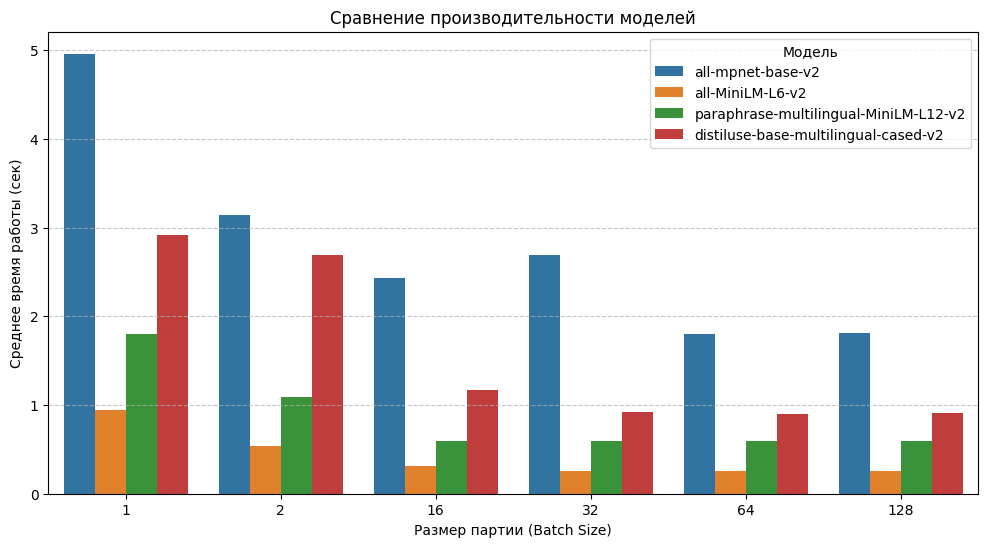

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Размер партии', y='Среднее время работы', hue='Модель')

plt.title('Сравнение производительности моделей')
plt.xlabel('Размер партии (Batch Size)')
plt.ylabel('Среднее время работы (сек)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

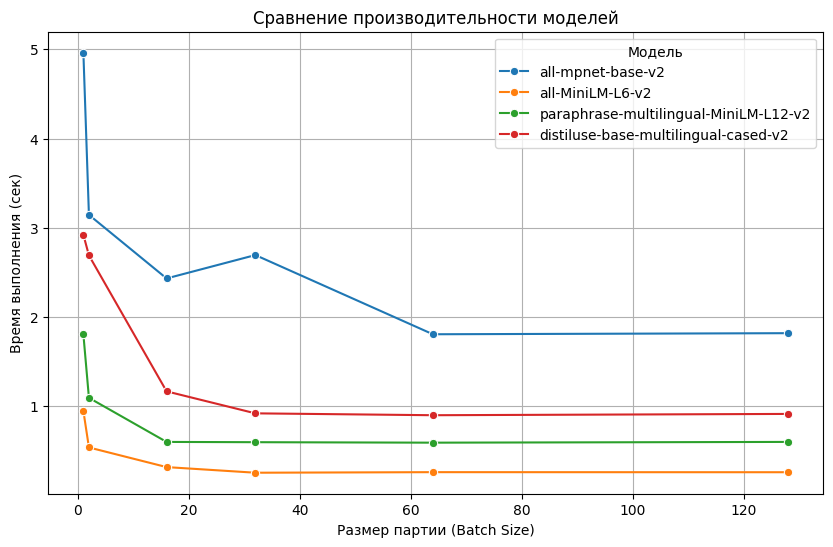

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Размер партии', y='Среднее время работы', hue='Модель', marker='o')

plt.title('Сравнение производительности моделей')
plt.xlabel('Размер партии (Batch Size)')
plt.ylabel('Время выполнения (сек)')
plt.grid(True)
plt.show()

#### Выводы

1.   Модель all-mpnet-base-v2 оказалась наиболее медленной по сравнению с другими, в то время как all-MiniLM-L6-v2 оказалась самой быстрой
2.   Все модели показали свой худший результат при размере партии 1
3. Оптимальный размер партии: от 16 до 32



### 2. Качество определения сходств

In [ ]:
pip install scipy

In [ ]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset
import time
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

models = ["all-mpnet-base-v2", "all-MiniLM-L6-v2", "paraphrase-multilingual-MiniLM-L12-v2", "distiluse-base-multilingual-cased-v2"]
dataset = load_dataset("sentence-transformers/stsb", split="test")
sentence1_list = dataset["sentence1"]
sentence2_list = dataset["sentence2"]
dataset = dataset.map(lambda x: {"norm_score": x["score"] / 5.0})
scores = dataset["norm_score"]
results = []

for model_name in models:
  model = SentenceTransformer(model_name)
  sentence1 = model.encode(sentence1_list, convert_to_tensor=True, batch_size=32)
  sentence2 = model.encode(sentence2_list, convert_to_tensor=True, batch_size=32)
  similar = util.cos_sim(sentence1, sentence2).diag().cpu().numpy()

  errors = np.abs(similar - scores)
  pearson = pearsonr(similar, scores)
  spearman = spearmanr(similar, scores)
  mae = np.mean(errors)
  max_error = np.max(errors)

  results.append({
      "Модель": model_name,
      "Pearson": pearson[0],
      "Spearman": spearman[0],
      "MAE": mae,
      "Максимальная ошибка": max_error
  })

df = pd.DataFrame(results)
display(df)





Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

,Модель,Pearson,Spearman,MAE,Максимальная ошибка
0,all-mpnet-base-v2,0.840407,0.834222,0.489243,0.861041
1,all-MiniLM-L6-v2,0.827400,0.820301,0.505488,0.864992
2,paraphrase-multilingual-MiniLM-L12-v2,0.834205,0.844150,0.533488,0.873128
3,distiluse-base-multilingual-cased-v2,0.816812,0.807526,0.547449,0.882668


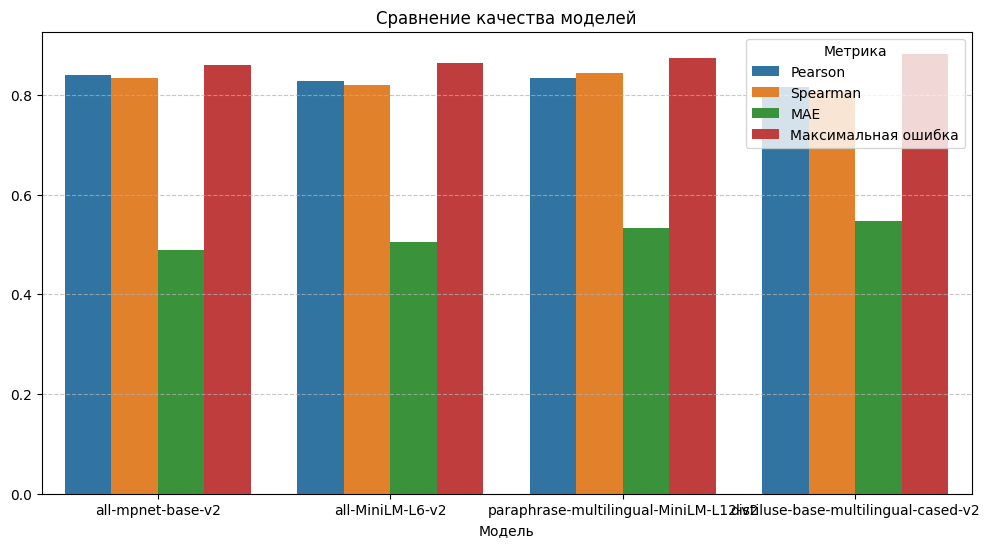

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_melted = df.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Модель', y='Значение', hue='Метрика')

plt.title('Сравнение качества моделей')
plt.ylabel('')
plt.xlabel('Модель')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Вывод
1. Использование метрики MAE неэффективно для определения качества сравнения
2. Модель all-mpnet-base-v2 показала себя как самая точная за счёт использования mpnet
3. Модель all-MiniLM-L6-v2 показала меньшую точность по сравнению с другими

### 3. IT-термины и корректное распознание русского языка

In [ ]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset
import time
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

semantic_dataset = {
    "categories": {
        "it_slang_equivalent": [
            {"s1": "Я задеплоил фикс на прод", "s2": "Я выложил исправление на боевой сервер", "score": 0.95, "note": "деплой = выкладка"},
            {"s1": "Нужно сделать мерж реквест", "s2": "Нужно создать запрос на слияние кода", "score": 0.95, "note": "merge = слияние"},
            {"s1": "Бэкенд упал", "s2": "Серверная часть недоступна", "score": 0.90, "note": "бэкенд = серверная часть"},
            {"s1": "Фронтенд тормозит", "s2": "Клиентская часть работает медленно", "score": 0.90, "note": "фронтенд = клиентская часть"},
            {"s1": "Закоммить изменения", "s2": "Сохранить изменения в репозитории", "score": 0.85, "note": "коммит = сохранение"},
            {"s1": "Раскатить новую версию", "s2": "Развернуть обновлённую версию приложения", "score": 0.90, "note": "раскатить = развернуть"},
            {"s1": "Пулл реквест не проходит", "s2": "Запрос на слияние не принимается", "score": 0.90, "note": "PR = запрос на слияние"},
            {"s1": "Залить код на сервер", "s2": "Разместить код на удалённом сервере", "score": 0.85, "note": "залить = разместить"},
            {"s1": "Продакшен лежит", "s2": "Боевой сервер не работает", "score": 0.90, "note": "продакшен = боевой сервер"},
            {"s1": "Откатить релиз", "s2": "Вернуть предыдущую версию приложения", "score": 0.85, "note": "откатить = вернуть версию"},
        ],
        "it_different_concepts": [
            {"s1": "Бэкенд разработчик", "s2": "Фронтенд разработчик", "score": 0.30, "note": "разные специализации"},
            {"s1": "Базу данных удалить", "s2": "Сервер перезагрузить", "score": 0.15, "note": "разные действия"},
            {"s1": "API запрос", "s2": "HTML страница", "score": 0.20, "note": "разные технологии"},
            {"s1": "Джава скрипт", "s2": "Джава", "score": 0.25, "note": "hard negative - похожие названия"},
            {"s1": "Git коммит", "s2": "Git ветка", "score": 0.35, "note": "разные понятия в git"},
            {"s1": "Docker контейнер", "s2": "Виртуальная машина", "score": 0.40, "note": "похожие технологии, но разные"},
            {"s1": "REST API", "s2": "GraphQL запрос", "score": 0.35, "note": "разные подходы к API"},
            {"s1": "SQL запрос", "s2": "NoSQL база", "score": 0.25, "note": "разные технологии"},
            {"s1": "Юнит тест", "s2": "Интеграционный тест", "score": 0.40, "note": "разные уровни тестирования"},
            {"s1": "Кэш очистить", "s2": "Базу данных очистить", "score": 0.30, "note": "разные хранилища"},
        ],
        "homonyms_it_vs_life": [
            {"s1": "Открой порт", "s2": "Открой окно", "score": 0.35, "note": "похожее действие, разный контекст"},
            {"s1": "Поток данных", "s2": "Речной поток", "score": 0.20, "note": "IT vs физика"},
            {"s1": "Коммит в гит", "s2": "Обязательство перед людьми", "score": 0.10, "note": "полная омонимия"},
            {"s1": "Мышь компьютерная", "s2": "Мышь живая", "score": 0.15, "note": "разные объекты"},
            {"s1": "Облачное хранилище", "s2": "Облако на небе", "score": 0.10, "note": "метафора vs реальность"},
            {"s1": "Папка на рабочем столе", "s2": "Папка в шкафу", "score": 0.25, "note": "цифровая vs физическая"},
            {"s1": "Вирус на компьютере", "s2": "Вирус в организме", "score": 0.20, "note": "разные типы вирусов"},
            {"s1": "Спам в почте", "s2": "Спам в еде", "score": 0.15, "note": "разные значения"},
            {"s1": "Печать документа", "s2": "Печать на бумаге", "score": 0.70, "note": "близкие значения"},
            {"s1": "Сетевой кабель", "s2": "Электрический кабель", "score": 0.50, "note": "похожие объекты"},
        ],
        "russian_morphology": [
            {"s1": "Разработчик пишет код", "s2": "Код пишется разработчиком", "score": 0.95, "note": "активный vs пассивный залог"},
            {"s1": "Ошибка в продакшене", "s2": "Ошибки в продакшене", "score": 0.90, "note": "единственное vs множественное"},
            {"s1": "Быстрый сервер", "s2": "Сервер, который быстро работает", "score": 0.90, "note": "прилагательное vs описание"},
            {"s1": "Программисты пишут программы", "s2": "Программа пишется программистами", "score": 0.85, "note": "число + залог"},
            {"s1": "На сервере ошибка", "s2": "Ошибка на сервере", "score": 0.95, "note": "порядок слов"},
            {"s1": "В базе данных запись", "s2": "Запись в базе данных", "score": 0.95, "note": "порядок слов"},
            {"s1": "Создать новый файл", "s2": "Новый файл создать", "score": 0.90, "note": "инверсия"},
            {"s1": "Удалить старый код", "s2": "Старый код удалить", "score": 0.90, "note": "инверсия"},
            {"s1": "Запустить тесты", "s2": "Тесты запустить", "score": 0.90, "note": "инверсия"},
            {"s1": "Команда разработчиков", "s2": "Разработчики команды", "score": 0.70, "note": "изменение смысла"},
        ],

        "semantic_traps": [
            {"s1": "Кот ест рыбу", "s2": "Рыба ест кота", "score": 0.10, "note": "полная инверсия смысла"},
            {"s1": "Разработчик исправил баг", "s2": "Баг исправил разработчика", "score": 0.15, "note": "грамматическая ошибка меняет смысл"},
            {"s1": "Сервер обрабатывает запросы", "s2": "Запросы обрабатывают сервер", "score": 0.20, "note": "субъект vs объект"},
            {"s1": "Пользователь нажал кнопку", "s2": "Кнопка нажала пользователя", "score": 0.05, "note": "абсурдная инверсия"},
            {"s1": "Клиент отправил данные", "s2": "Данные отправили клиента", "score": 0.10, "note": "инверсия ролей"},
            {"s1": "Админ заблокировал пользователя", "s2": "Пользователь заблокировал админа", "score": 0.25, "note": "инверсия субъектов"},
            {"s1": "Тест проходит сборку", "s2": "Сборка проходит тест", "score": 0.30, "note": "разный смысл"},
            {"s1": "Код компилирует программист", "s2": "Программист компилирует код", "score": 0.85, "note": "допустимая инверсия"},
            {"s1": "База хранит данные", "s2": "Данные хранят базу", "score": 0.15, "note": "инверсия смысла"},
            {"s1": "Лог записывает события", "s2": "События записывают лог", "score": 0.40, "note": "частичная инверсия"},
        ],
        "synonyms_paraphrases": [
            {"s1": "Приложение работает медленно", "s2": "Программа тормозит", "score": 0.85, "note": "синонимы приложение/программа"},
            {"s1": "Система зависла", "s2": "Программа не отвечает", "score": 0.80, "note": "синонимичные описания"},
            {"s1": "Нужно исправить ошибку", "s2": "Требуется устранить баг", "score": 0.90, "note": "ошибка = баг"},
            {"s1": "Перезагрузи сервер", "s2": "Рестартни сервер", "score": 0.90, "note": "перезагрузи = рестартни"},
            {"s1": "Проверь логи", "s2": "Посмотри журналы", "score": 0.80, "note": "логи = журналы"},
            {"s1": "Обнови зависимости", "s2": "Обновите пакеты", "score": 0.75, "note": "зависимости = пакеты"},
            {"s1": "Собери проект", "s2": "Сбилдь проект", "score": 0.85, "note": "собери = сбилдь"},
            {"s1": "Запуш изменения", "s2": "Отправь изменения в репозиторий", "score": 0.85, "note": "запуш = отправь"},
            {"s1": "Отладь код", "s2": "Найди и исправь ошибки в коде", "score": 0.80, "note": "отладь = найди ошибки"},
            {"s1": "Оптимизируй запрос", "s2": "Ускорь выполнение запроса", "score": 0.85, "note": "оптимизируй = ускорь"},
        ],

        "context_dependency": [
            {"s1": "Порт открыт для подключения", "s2": "Порт открыт для кораблей", "score": 0.30, "note": "IT порт vs морской порт"},
            {"s1": "Создай ветку в репо", "s2": "Создай ветку дерева", "score": 0.15, "note": "git ветка vs дерево"},
            {"s1": "Запусти сервер", "s2": "Запусти официанта", "score": 0.20, "note": "IT сервер vs человек"},
            {"s1": "Клиент не отвечает", "s2": "Покупатель не отвечает", "score": 0.50, "note": "IT клиент vs покупатель"},
            {"s1": "Домен не доступен", "s2": "Домен не зарегистрирован", "score": 0.60, "note": "близкие IT понятия"},
            {"s1": "Хост не найден", "s2": "Ведущий не найден", "score": 0.20, "note": "IT хост vs человек"},
            {"s1": "Токен не действителен", "s2": "Жетон не действителен", "score": 0.40, "note": "IT токен vs физический"},
            {"s1": "Кукис истёк", "s2": "Печенье истёкло", "score": 0.15, "note": "cookies vs еда"},
            {"s1": "Сокет закрыт", "s2": "Розетка закрыта", "score": 0.25, "note": "socket vs розетка"},
            {"s1": "Драйвер не установлен", "s2": "Водитель не установлен", "score": 0.10, "note": "driver vs водитель"},
        ],
        "similarity_gradient": [
            {"s1": "Полная копия системы", "s2": "Полная копия системы", "score": 1.00, "note": "идентичные фразы"},
            {"s1": "Полная копия системы", "s2": "Точная копия системы", "score": 0.95, "note": "синонимы полная/точная"},
            {"s1": "Полная копия системы", "s2": "Частичная копия системы", "score": 0.60, "note": "различие полная/частичная"},
            {"s1": "Полная копия системы", "s2": "Похожая система", "score": 0.40, "note": "копия vs похожая"},
            {"s1": "Полная копия системы", "s2": "Другая система", "score": 0.15, "note": "противоположность"},
            {"s1": "Система работает", "s2": "Система функционирует", "score": 0.90, "note": "синонимы"},
            {"s1": "Система работает", "s2": "Система не работает", "score": 0.10, "note": "отрицание"},
            {"s1": "Система работает быстро", "s2": "Система работает медленно", "score": 0.25, "note": "антонимы"},
            {"s1": "Система работает быстро", "s2": "Система функционирует быстро", "score": 0.90, "note": "синонимы работает/функционирует"},
            {"s1": "Система работает быстро", "s2": "Система работает", "score": 0.70, "note": "общее vs конкретное"},
        ],
    },

    "metadata": {
        "total_pairs": 80,
        "language": "ru",
        "domains": ["IT", "general", "slang"],
        "score_range": [0.0, 1.0],
        "categories_count": 8,
    }
}

models = ["all-mpnet-base-v2", "all-MiniLM-L6-v2", "paraphrase-multilingual-MiniLM-L12-v2", "distiluse-base-multilingual-cased-v2"]
results = []

for model_name in models:
  model = SentenceTransformer(model_name)

  categories = semantic_dataset["categories"]
  model_results = []
  for category, pairs in categories.items():
    sentence1_list = []
    sentence2_list = []
    scores = []
    for pair in pairs:
      sentence1_list.append(pair["s1"])
      sentence2_list.append(pair["s2"])
      scores.append(pair["score"])

    sentence1 = model.encode(sentence1_list, convert_to_tensor=True, batch_size=32)
    sentence2 = model.encode(sentence2_list, convert_to_tensor=True, batch_size=32)
    similar = util.cos_sim(sentence1, sentence2).diag().cpu().numpy()
    errors = np.abs(similar - scores)
    pearson = pearsonr(similar, scores)
    spearman = spearmanr(similar, scores)
    mae = np.mean(errors)
    max_error = np.max(errors)
    model_results.append({
      "Категория": category,
      "Pearson": pearson[0],
      "Spearman": spearman[0],
      "MAE": mae,
      "Максимальная ошибка": max_error
    })
  results.append({
  "Модель": model_name,
  "Результаты": model_results
  })

df_results = pd.DataFrame(results)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
model_dfs = {}

for model_entry in results:
    model_name = model_entry['Модель']
    df_model = pd.DataFrame(model_entry['Результаты'])
    model_dfs[model_name] = df_model

    print(f"\nРезультаты для модели: {model_name}")
    display(df_model)


Результаты для модели: all-mpnet-base-v2


,Категория,Pearson,Spearman,MAE,Максимальная ошибка
0,it_slang_equivalent,-0.345911,-0.289499,0.265226,0.346076
1,it_different_concepts,-0.061586,-0.012271,0.353366,0.563559
2,homonyms_it_vs_life,0.161756,0.366988,0.475927,0.650470
3,russian_morphology,0.088529,0.321251,0.072756,0.236104
4,semantic_traps,0.166179,0.262200,0.694049,0.878892
5,synonyms_paraphrases,0.012720,-0.025426,0.115269,0.286030
6,context_dependency,-0.208315,0.286591,0.523983,0.685963
7,similarity_gradient,0.253154,0.285716,0.303664,0.852097



Результаты для модели: all-MiniLM-L6-v2


,Категория,Pearson,Spearman,MAE,Максимальная ошибка
0,it_slang_equivalent,-0.079476,-0.184226,0.261971,0.452050
1,it_different_concepts,-0.197169,-0.153386,0.325874,0.551315
2,homonyms_it_vs_life,0.352036,0.434269,0.456043,0.676221
3,russian_morphology,0.195395,0.399925,0.075130,0.234595
4,semantic_traps,0.486680,0.506107,0.702230,0.880102
5,synonyms_paraphrases,-0.063582,-0.057208,0.144512,0.309559
6,context_dependency,-0.440520,-0.195126,0.500307,0.744233
7,similarity_gradient,0.267006,0.328269,0.309299,0.879452



Результаты для модели: paraphrase-multilingual-MiniLM-L12-v2


,Категория,Pearson,Spearman,MAE,Максимальная ошибка
0,it_slang_equivalent,-0.397382,-0.486884,0.433468,0.834908
1,it_different_concepts,0.401132,0.404938,0.261729,0.640117
2,homonyms_it_vs_life,0.548194,0.409803,0.300013,0.607699
3,russian_morphology,0.487380,0.229465,0.076934,0.173056
4,semantic_traps,0.511866,0.378056,0.598245,0.855352
5,synonyms_paraphrases,0.530238,0.508513,0.213671,0.483714
6,context_dependency,0.316507,0.353665,0.450092,0.713646
7,similarity_gradient,0.905117,0.863226,0.212939,0.576618



Результаты для модели: distiluse-base-multilingual-cased-v2


,Категория,Pearson,Spearman,MAE,Максимальная ошибка
0,it_slang_equivalent,-0.168720,-0.236863,0.423387,0.716760
1,it_different_concepts,0.273298,0.214740,0.277974,0.556496
2,homonyms_it_vs_life,0.702052,0.678928,0.354103,0.587139
3,russian_morphology,0.317430,0.242577,0.068587,0.216789
4,semantic_traps,0.054354,-0.103660,0.668814,0.909759
5,synonyms_paraphrases,0.409333,0.495801,0.250055,0.499347
6,context_dependency,0.007721,-0.060977,0.531189,0.741543
7,similarity_gradient,0.577237,0.668696,0.234127,0.718463


Перенесем все в "плоский" df для построения графиков

In [ ]:
from copy import deepcopy
flat_results = []

for model_entry in results:
    model_name = model_entry['Модель']
    for category_res in model_entry['Результаты']:
        row = deepcopy(category_res)
        row['Модель'] = model_name
        flat_results.append(row)

df_semantic = pd.DataFrame(flat_results)

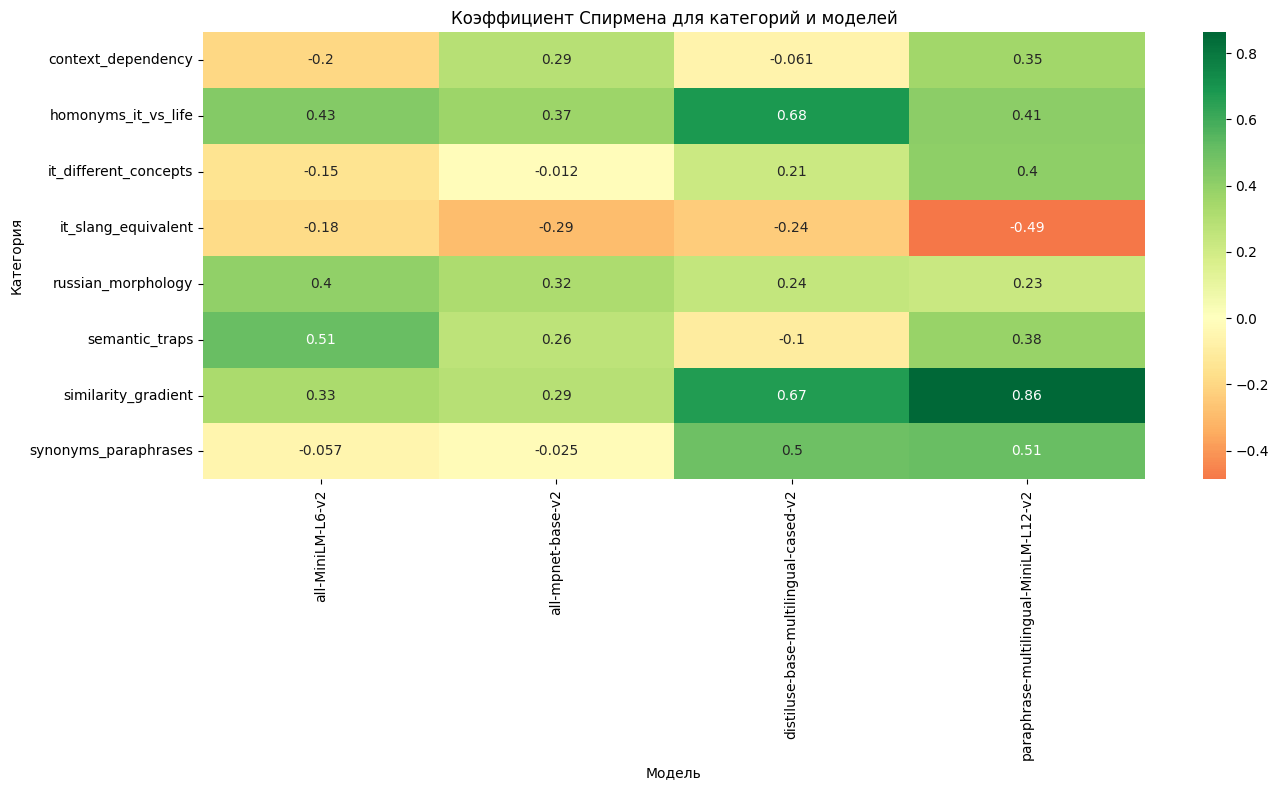

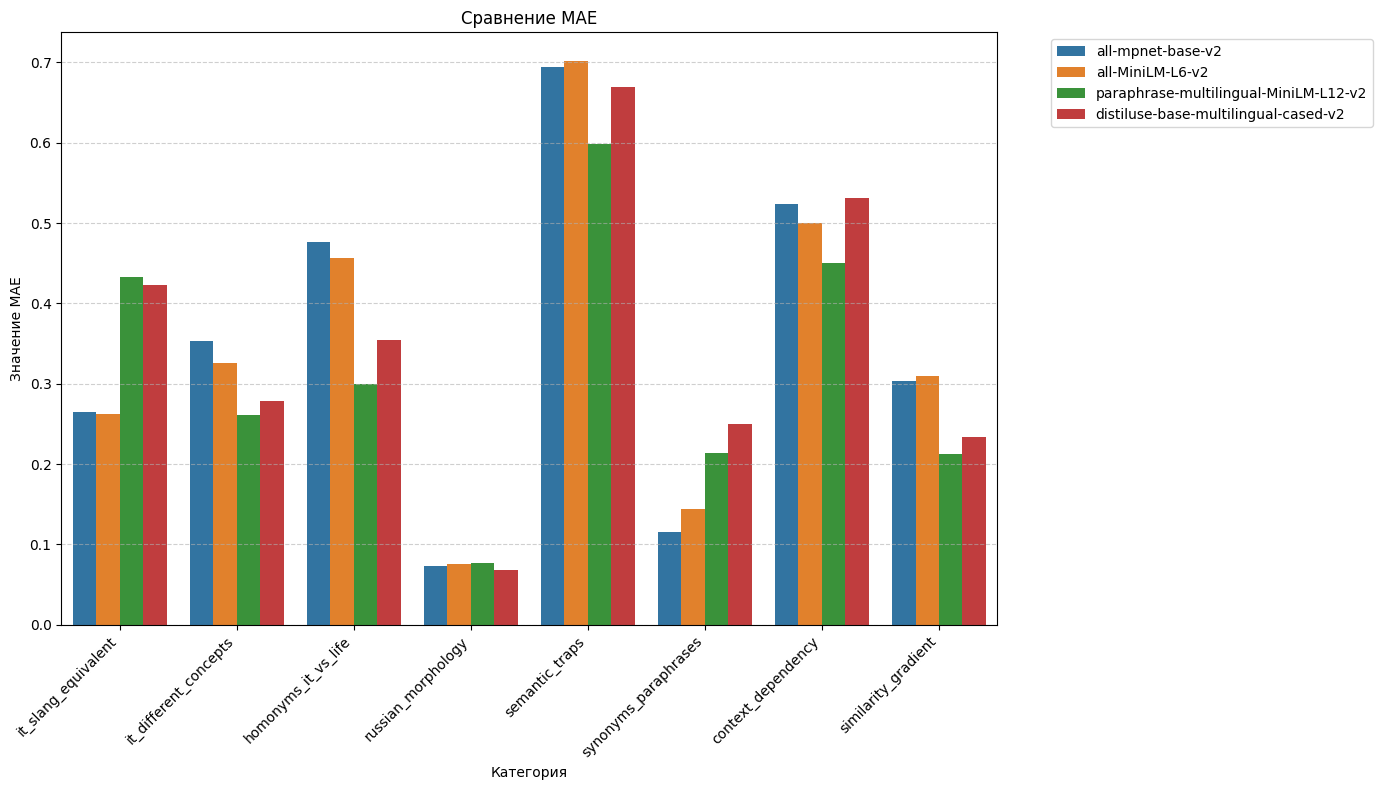

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
spearman_pivot = df_semantic.pivot(index='Категория', columns='Модель', values='Spearman')
sns.heatmap(spearman_pivot, annot=True, cmap='RdYlGn', center=0)
plt.title('Коэффициент Спирмена для категорий и моделей')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
sns.barplot(data=df_semantic, x='Категория', y='MAE', hue='Модель')
plt.title('Сравнение MAE')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Значение MAE')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Вывод
1. Ни одна модель не готова к продакшену без предварительного дообучения
2. Слабая сторона всех моделей - it сленг. Модели показывают отрицательный коэфициент. Это означает, что если человек оценивает схожесть выше, модель оценивает ее ниже и наоборот
3. С русским языком способны корректно работать только две модели


## Итоговый рейтинг моделей
Рейтинг составлен, основываясь на главные требования от модели

| Место | Модель |
|:-----:|--------|
| 🥇 | `paraphrase-multilingual-MiniLM-L12-v2`
| 🥈 | `distiluse-base-multilingual-cased-v2`
| 🥉 | `all-MiniLM-L6-v2`
| 4 | `all-mpnet-base-v2` |

---

Для продакшена планируется использование модели `paraphrase-multilingual-MiniLM-L12-v2` с дообучением для понимания it терминологии.
Ожидаемый прирост Spearman до 0.6-0.8
